In [1]:
import networkx as nx
from IPython.display import HTML
from heuristics import HD, CHD
from utils import load_graph
import matplotlib.pyplot as plt
from matplotlib import patches
from models import threshold_norm
from matplotlib.ticker import MaxNLocator
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LinearSegmentedColormap

## Simulation visualization

For the paper, I want to show a visualization of how an information cascade occurs. The village dataset, with 180 nodes, is an ideal size for a small scale model.

The simulation will be repeated until one finished in n timesteps is found. Images of the network at regular intervals of the max timestep will then be used to illustrate the cascade. Nodes activated within the last 5 timesteps will be colored according to a gradient based on recency. Nodes activated in older timesteps will retain the "least recent" color.

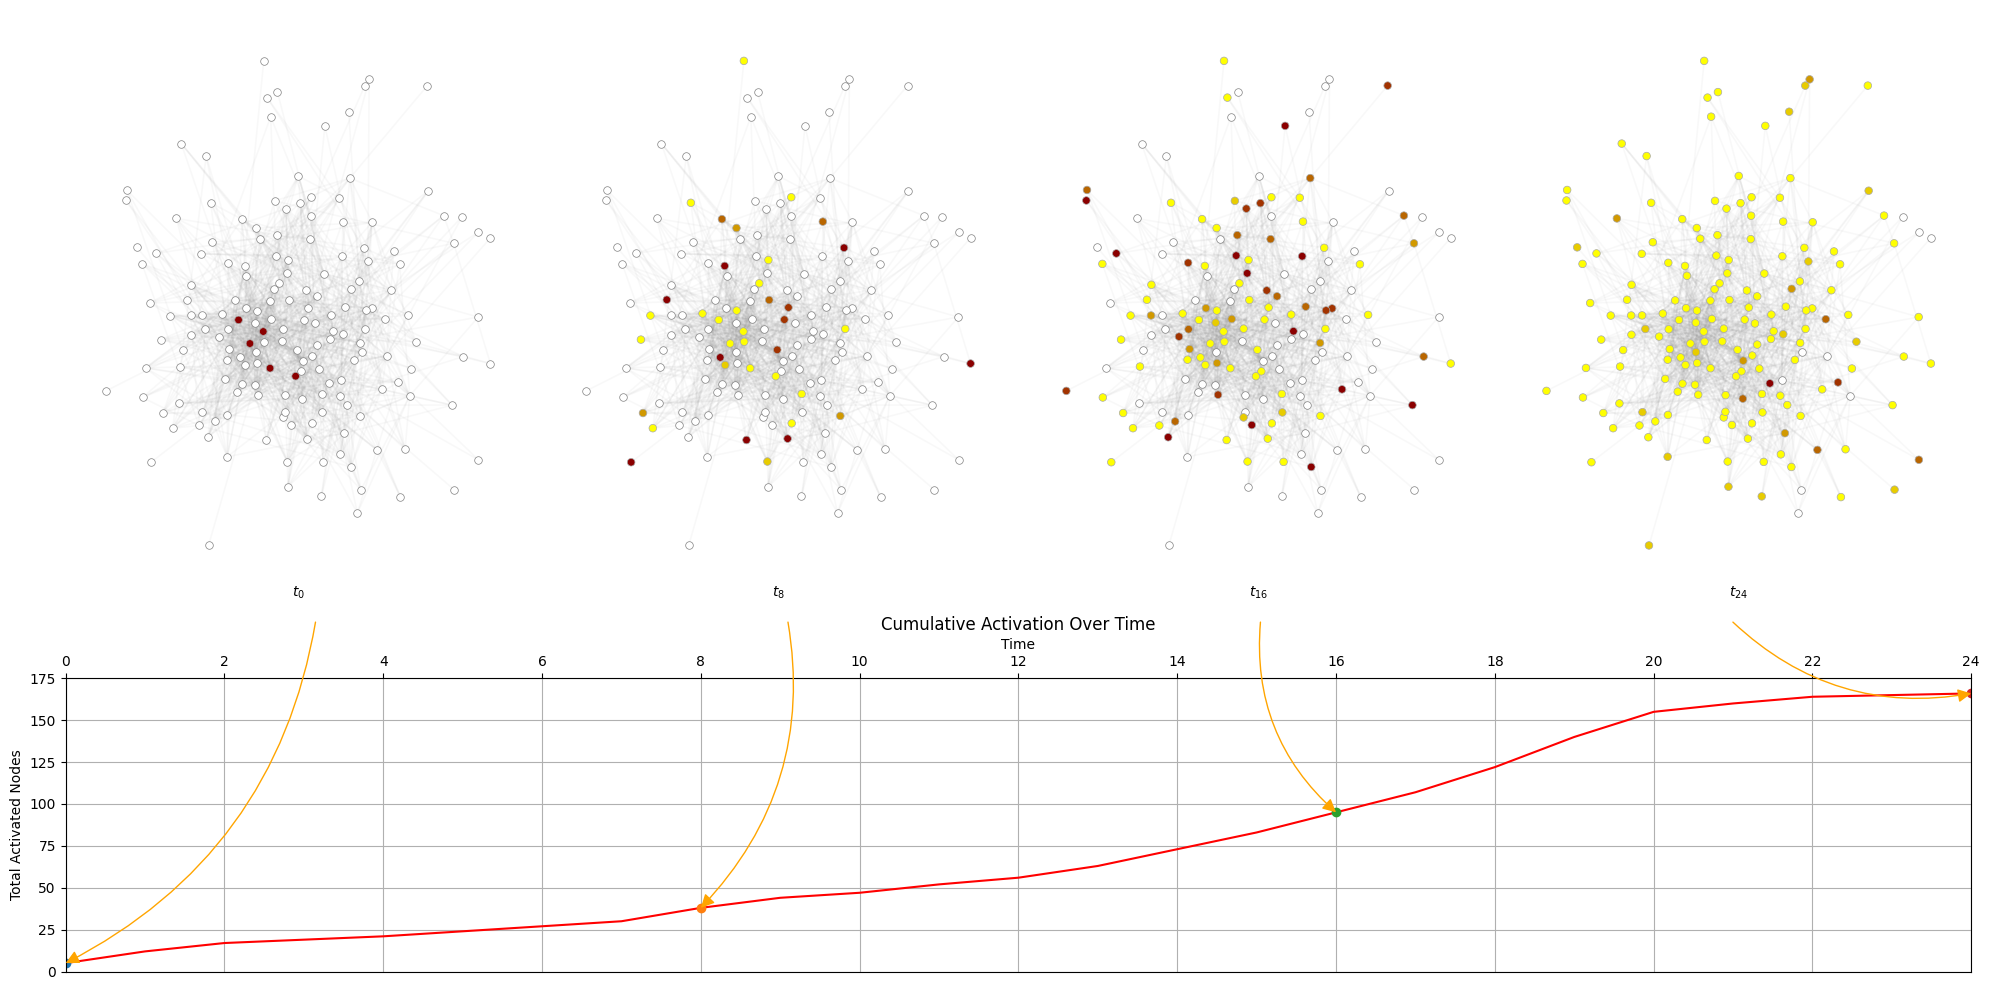

In [2]:
G = load_graph("datasets_ignored/village.csv")

# Removing isolates
isolates = nx.isolates(G)
G.remove_nodes_from(list(isolates))

seeds = HD(G, 5)

# Find a simulation that runs in the desired number of timesteps
while True:
    activation_time = threshold_norm(G, seeds, 0.4, 0.25)   # params consistently give a global cascade
    if max(activation_time.values()) == 24:
        break

# Network layout
pos = nx.spring_layout(G, seed=42, k=0.5, weight=1.2, scale=1.3, iterations=40)

# Precompute cumulative activations over time
max_t = max(activation_time.values())
timesteps = range(max_t + 1) # TODO: Does this need + 1?
cumulative_counts = [sum(1 for t in activation_time.values() if t <= frame) for frame in timesteps]

""" # Set up figure and color map
cmap = LinearSegmentedColormap.from_list("red_yellow", ["yellow", "darkred"])
fig, (ax_graph, ax_plot) = plt.subplots(1, 2, figsize=(15, 8))

def update(frame):
    ax_graph.clear()
    ax_plot.clear()
    
    # Nodes that have been activated by this timestep
    active_nodes = [n for n, t in activation_time.items() if t <= frame]
    inactive_nodes = [n for n in G.nodes() if n not in active_nodes]

    # Draw inactive nodes
    nx.draw_networkx_nodes(G, pos,
                           nodelist=inactive_nodes,
                           node_color="white",
                           linewidths=0.5,
                           edgecolors="gray",
                           node_size=30,
                           ax=ax_graph)

    # Compute colors for active nodes
    node_colors = []
    for n in active_nodes:
        t = activation_time[n]
        age = frame - t  # How many timesteps since activation
        
        if age >= 5:
            color_val = 0.0  # fully yellow for old nodes
        else:
            color_val = 1 - (age / 5)  # linear fade from red (recent) to yellow (5 steps ago)
        
        node_colors.append(cmap(color_val))
    
    nx.draw_networkx_nodes(G, pos,
                           nodelist=active_nodes,
                           node_color=node_colors,
                           linewidths=0.5,
                           edgecolors="darkgray",
                           node_size=30,
                           ax=ax_graph)

    nx.draw_networkx_edges(G, pos=pos,
                           edge_color="gray",
                           width=1.2,
                           alpha=0.05,
                           ax=ax_graph)

    ax_graph.set_title(f"Timestep {frame}")
    ax_graph.axis("off")

    ax_plot.plot(timesteps[:frame+1], cumulative_counts[:frame+1], color="red")
    ax_plot.set_xlim(0, max_t)
    ax_plot.set_ylim(0, len(G.nodes()))
    ax_plot.set_xlabel("Time")
    ax_plot.set_ylabel("Total Activated Nodes")
    ax_plot.set_title("Cumulative Activation Over Time")
    ax_plot.grid(True)

anim = FuncAnimation(fig, update, frames=timesteps, interval=800, repeat=False)

HTML(anim.to_jshtml())
"""

selected_frames = [0, 8, 16, 24]
n_frames = len(selected_frames)

# Set up figure with GridSpec
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, n_frames, height_ratios=[2, 1])  # bottom row slightly taller

# Top row: individual network snapshots
graph_axes = [fig.add_subplot(gs[0, i]) for i in range(n_frames)]

# Bottom row: single cumulative plot spanning all columns
plot_ax = fig.add_subplot(gs[1, :])  # span all columns

cmap = LinearSegmentedColormap.from_list("red_yellow", ["yellow", "darkred"])

for i, frame in enumerate(selected_frames):
    ax_graph = graph_axes[i]

    # Nodes activated by this timestep
    active_nodes = [n for n, t in activation_time.items() if t <= frame]
    inactive_nodes = [n for n in G.nodes() if n not in active_nodes]

    # Draw inactive nodes
    nx.draw_networkx_nodes(G, pos,
                           nodelist=inactive_nodes,
                           node_color="white",
                           linewidths=0.5,
                           edgecolors="gray",
                           node_size=30,
                           ax=ax_graph)

    # Colors for active nodes
    node_colors = []
    for n in active_nodes:
        t = activation_time[n]
        age = frame - t
        color_val = 0.0 if age >= 5 else 1 - (age / 5)
        node_colors.append(cmap(color_val))

    nx.draw_networkx_nodes(G, pos,
                           nodelist=active_nodes,
                           node_color=node_colors,
                           linewidths=0.5,
                           edgecolors="darkgray",
                           node_size=30,
                           ax=ax_graph)

    nx.draw_networkx_edges(G, pos=pos,
                           edge_color="gray",
                           width=1.2,
                           alpha=0.05,
                           ax=ax_graph)

    ax_graph.text(
        0.5, 0, fr"$t_{{{frame}}}$",
        transform=ax_graph.transAxes,
        ha='center'
    )
    ax_graph.axis("off")

# Bottom cumulative plot
plot_ax.plot(timesteps, cumulative_counts, color="red")
plot_ax.set_xlim(0, max_t)
plot_ax.set_ylim(0, len(G.nodes()))
plot_ax.xaxis.tick_top()
plot_ax.xaxis.set_label_position("top")
plot_ax.set_xlabel("Time")
plot_ax.set_ylabel("Total Activated Nodes")
plot_ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plot_ax.yaxis.set_major_locator(MaxNLocator(nbins=7))
plot_ax.set_title("Cumulative Activation Over Time")
plot_ax.grid(True)


for i, frame in enumerate(selected_frames):
    ax_graph = graph_axes[i]

    # Bottom center of graph subplot (in figure coordinates)
    graph_pos = ax_graph.get_position()
    x_graph = graph_pos.x0 + graph_pos.width / 2
    y_graph = graph_pos.y0 - 0.5

    # Convert to figure fraction for ConnectionPatch
    xyA = ax_graph.transAxes.transform((x_graph, y_graph))  # pixels
    xyA_fig = fig.transFigure.inverted().transform(xyA)     # figure fraction

    # Convert (frame, 0) from plot_ax data → figure coords
    point = frame, cumulative_counts[frame]
    plot_ax.plot(*point, "o")

    arrow = patches.ConnectionPatch(
        xyA_fig,
        point,
        coordsA='figure fraction',
        coordsB=plot_ax.transData,
        # Default shrink parameter is 0 so can be omitted
        color="orange",
        arrowstyle="-|>",  # "normal" arrow
        mutation_scale=20,  # controls arrow head size
        connectionstyle=f"arc3,rad={-0.25 if i < 2 else 0.25}",
        linewidth=1,
    )

    fig.add_artist(arrow)

plt.tight_layout()
plt.show()


In [ ]:


""" selected_frames = [0, 8, 16, 24]
n_frames = len(selected_frames)

# Set up figure with GridSpec
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, n_frames, height_ratios=[2, 1])  # bottom row slightly taller

# Top row: individual network snapshots
graph_axes = [fig.add_subplot(gs[0, i]) for i in range(n_frames)]

# Bottom row: single cumulative plot spanning all columns
plot_ax = fig.add_subplot(gs[1, :])  # span all columns

cmap = LinearSegmentedColormap.from_list("red_yellow", ["yellow", "darkred"])

for i, frame in enumerate(selected_frames):
    ax_graph = graph_axes[i]

    # Nodes activated by this timestep
    active_nodes = [n for n, t in activation_time.items() if t <= frame]
    inactive_nodes = [n for n in G.nodes() if n not in active_nodes]

    # Draw inactive nodes
    nx.draw_networkx_nodes(G, pos,
                           nodelist=inactive_nodes,
                           node_color="white",
                           linewidths=0.5,
                           edgecolors="gray",
                           node_size=30,
                           ax=ax_graph)

    # Colors for active nodes
    node_colors = []
    for n in active_nodes:
        t = activation_time[n]
        age = frame - t
        color_val = 0.0 if age >= 5 else 1 - (age / 5)
        node_colors.append(cmap(color_val))

    nx.draw_networkx_nodes(G, pos,
                           nodelist=active_nodes,
                           node_color=node_colors,
                           linewidths=0.5,
                           edgecolors="darkgray",
                           node_size=30,
                           ax=ax_graph)

    nx.draw_networkx_edges(G, pos=pos,
                           edge_color="gray",
                           width=1.2,
                           alpha=0.05,
                           ax=ax_graph)

    ax_graph.text(
        0.5, 0, fr"$t_{{{frame}}}$",
        transform=ax_graph.transAxes,
        ha='center'
    )
    ax_graph.axis("off")

# Bottom cumulative plot
plot_ax.plot(timesteps, cumulative_counts, color="red")
plot_ax.set_xlim(0, max_t)
plot_ax.set_ylim(0, len(G.nodes()))
plot_ax.xaxis.tick_top()
plot_ax.xaxis.set_label_position("top")
plot_ax.set_xlabel("Time")
plot_ax.set_ylabel("Total Activated Nodes")
plot_ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plot_ax.yaxis.set_major_locator(MaxNLocator(nbins=7))
plot_ax.set_title("Cumulative Activation Over Time")
plot_ax.grid(True)


for i, frame in enumerate(selected_frames):
    ax_graph = graph_axes[i]

    # Bottom center of graph subplot (in figure coordinates)
    graph_pos = ax_graph.get_position()
    x_graph = graph_pos.x0 + graph_pos.width / 2
    y_graph = graph_pos.y0 - 0.5

    # Convert to figure fraction for ConnectionPatch
    xyA = ax_graph.transAxes.transform((x_graph, y_graph))  # pixels
    xyA_fig = fig.transFigure.inverted().transform(xyA)     # figure fraction

    # Convert (frame, 0) from plot_ax data → figure coords
    point = frame, cumulative_counts[frame]
    plot_ax.plot(*point, "o")

    arrow = patches.ConnectionPatch(
        xyA_fig,
        point,
        coordsA='figure fraction',
        coordsB=plot_ax.transData,
        # Default shrink parameter is 0 so can be omitted
        color="orange",
        arrowstyle="-|>",  # "normal" arrow
        mutation_scale=20,  # controls arrow head size
        connectionstyle=f"arc3,rad={-0.25 if i < 2 else 0.25}",
        linewidth=1,
    )

    fig.add_artist(arrow)

plt.tight_layout()
plt.show() """

KeyboardInterrupt: 

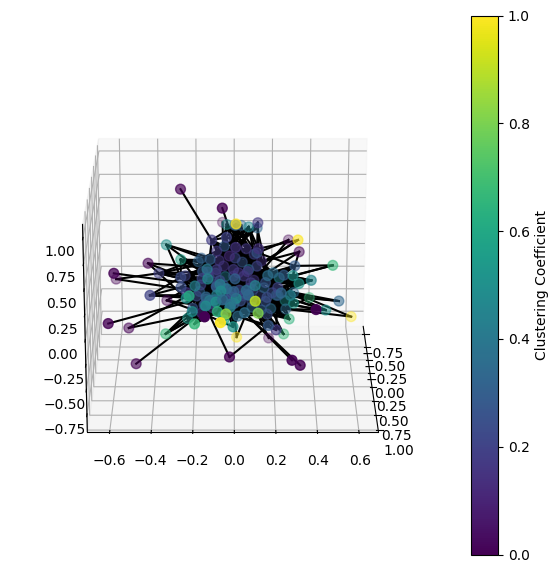

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML  # Ensure you have this import to display animations in Jupyter Notebooks

G = load_graph("datasets_ignored/village.csv")

# Removing isolates
isolates = nx.isolates(G)
G.remove_nodes_from(list(isolates))

# Compute the clustering coefficient for each node
clustering_coeffs = nx.clustering(G)

# Normalize the clustering coefficients for color scaling
# Use a simple min-max normalization for color scaling
min_cc = min(clustering_coeffs.values())
max_cc = max(clustering_coeffs.values())
norm = plt.Normalize(min_cc, max_cc)

# Generate 3D positions
pos = nx.spring_layout(G, dim=3)

# Extract node positions
x = [pos[n][0] for n in G.nodes()]
y = [pos[n][1] for n in G.nodes()]
z = [pos[n][2] for n in G.nodes()]

# Create 3D plot
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Draw nodes, coloring them based on clustering coefficient
node_colors = [clustering_coeffs[n] for n in G.nodes()]  # List of clustering coefficients for each node
sc = ax.scatter(x, y, z, c=node_colors, cmap='viridis', s=50, zorder=1)  # 'viridis' colormap

# Add a color bar to show the clustering coefficient scale
plt.colorbar(sc, ax=ax, label="Clustering Coefficient")

# Draw edges with a higher zorder to ensure they are on top of the nodes
for edge in G.edges():
    x_coords = [pos[edge[0]][0], pos[edge[1]][0]]
    y_coords = [pos[edge[0]][1], pos[edge[1]][1]]
    z_coords = [pos[edge[0]][2], pos[edge[1]][2]]
    ax.plot(x_coords, y_coords, z_coords, color='black', zorder=2)  # Edges above nodes

# Set an initial view
ax.view_init(elev=20, azim=30)

# Define the update function for animation
def update_view(angle):
    ax.view_init(elev=20, azim=angle)

# Create the animation
ani = FuncAnimation(fig, update_view, frames=np.arange(0, 360, 5), interval=50)

# Display the animation
HTML(ani.to_jshtml())